Linear regression was used as an interpretable baseline. To account for possible nonlinear relationships, selected predictors were transformed before fitting the model. However, these transformations require the functional form to be specified manually in advance.

The exploratory analysis showed that the relationships between insurance charges and predictors such as age and BMI may not be linear. Smoking status also showed a clear difference in the distribution and median of insurance charges. It is therefore plausible that the effect of BMI or age differs depending on smoking status.

We therefore selected a random forest regressor model as a more flexible alternative. Random forests are able to capture nonlinear relationships, threshold effects, and interactions between predictors without requiring the features to be transformed into another space. In addition, this model type is also suitable for our mixed dataset, which consists not only of numerical but also of categorical variables.

A random forest combines many decision trees. Each tree is trained on a slightly different sample of the data. For the inital model all predictors are available as candidates at each split. For our regression task, all tree predictions are averaged. Thereby, instability and overfitting are reduced compared with a single decision tree.


### **Load clean data**

In [1]:
import pandas as pd

data = pd.read_csv('../data/health_insurance_clean.csv')

X = data.drop(columns='charges') #select our predictor
y = data["charges"] #select our target variable

X.head()

,age,sex,bmi,children,smoker,region,blood_pressure,exercise_frequency,pre_existing_condition,occupation_risk,annual_income
0,19.0,female,27.900,0.0,yes,southwest,139.0,never,True,high,104158.67
1,18.0,male,33.770,1.0,no,southeast,129.9,weekly,True,moderate,43530.88
2,28.0,male,33.000,3.0,no,southeast,111.1,rarely,False,high,113004.75
3,33.0,male,22.705,0.0,no,northwest,126.9,rarely,False,high,185041.26
4,32.0,male,28.880,0.0,no,northwest,134.7,rarely,True,low,46747.97


### **Data Setup**

We need to encode our categorical variables. We convert them into numerical dummy variables because the model requires numerical input. We us One hot encoding for this. With `drop_first=True` we remove one category from each categorical variable to avoid saving a redundant column. We set `dtype=int`to store the dummy values as integers 0 or 1

In [2]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

X.head()

,age,bmi,children,blood_pressure,pre_existing_condition,annual_income,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,exercise_frequency_never,exercise_frequency_rarely,exercise_frequency_weekly,occupation_risk_low,occupation_risk_moderate
0,19.0,27.900,0.0,139.0,True,104158.67,0,1,0,0,1,1,0,0,0,0
1,18.0,33.770,1.0,129.9,True,43530.88,1,0,0,1,0,0,0,1,0,1
2,28.0,33.000,3.0,111.1,False,113004.75,1,0,0,1,0,0,1,0,0,0
3,33.0,22.705,0.0,126.9,False,185041.26,1,0,1,0,0,0,1,0,0,0
4,32.0,28.880,0.0,134.7,True,46747.97,1,0,1,0,0,0,1,0,1,0


Next we create the train test split with an 80:20 ratio:

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

### **Fit Random Forest model**

We start by training a basic random forest regressor with 500 (defaul value supported by Probst, Wright) decision trees. This first random forest model will serve as a starting point before tuning its hyperparameters.

In [4]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=500, random_state=67)

model.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Now we continue with making the predictions:

In [5]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

Evaluate the first random forest model: 

In [6]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [7]:
print("Training MAE:", round(train_mae, 3))
print("Test MAE:", round(test_mae, 3))

print("Training RMSE:", round(train_rmse, 3))
print("Test RMSE:", round(test_rmse, 3))

print("Training R^2:", round(train_r2, 3))
print("Test R^2:", round(test_r2, 3))

Training MAE: 1018.737
Test MAE: 2716.86
Training RMSE: 1787.93
Test RMSE: 4763.828
Training R^2: 0.979
Test R^2: 0.806


The initial random forest achieved a test: MAE of 2716.86, RMSE of 4763.828,  R^2 of 0.806. This shows that the model explains about 80,5% of the variance in the insurance charges on our test set. But the training performance is currently better. There is a clear gap between training and test performance which indicates that the model is overfitting the training data. The reasonable next step is to evaluate the model using cross validation and to reduce its complexity with some hyperparameter tuning.

Since the initial evaluation is based on only one train test split, the results may depend on the particular split used. We therefore apply cross validation to test whether the random forest performs consistently across different subsets of the training data.

In [8]:
from sklearn.model_selection import cross_validate, KFold
import numpy as np

metrics = {
    "mae": "neg_mean_absolute_error", #Scikit lean uses internally within cross validation negative mae and rmse values
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=67
)

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv, # standard value 5 splits
    scoring=metrics,
    return_train_score=True #return also training metrics to see overfitting
)

train_mae_cv = -cv_results["train_mae"]
val_mae_cv = -cv_results["test_mae"]

train_rmse_cv = -cv_results["train_rmse"]
val_rmse_cv = -cv_results["test_rmse"]

train_r2_cv = cv_results["train_r2"]
val_r2_cv = cv_results["test_r2"]

In [9]:
print("Training MAE:", round(train_mae_cv.mean(), 3), "Std:", round(train_mae_cv.std(), 3))
print("Validation MAE:", round(val_mae_cv.mean(), 3), "Std:", round(val_mae_cv.std(), 3))

print("Training RMSE:", round(train_rmse_cv.mean(), 3), "Std:", round(train_rmse_cv.std(), 3))
print("Validation RMSE:", round(val_rmse_cv.mean(), 3), "Std:", round(val_rmse_cv.std(), 3))

print("Training R^2:", round(train_r2_cv.mean(), 3), "Std:", round(train_r2_cv.std(), 3))
print("Validation R^2:", round(val_r2_cv.mean(), 3), "Std:", round(val_r2_cv.std(), 3))

Training MAE: 1007.531 Std: 27.354
Validation MAE: 2797.85 Std: 138.931
Training RMSE: 1776.741 Std: 30.179
Validation RMSE: 4869.51 Std: 324.663
Training R^2: 0.979 Std: 0.001
Validation R^2: 0.843 Std: 0.024


The random forest achieved here a mean validation MAE of: 2797.85, RMSE of: 4869.51 and R^2 of: 0.843. The realive limited variation across folds shows that the observed performance gap is not the result of on particualr train validation split. But as already seen with the basic train test split the training scores are still clearly better thatn the validation scores. The training validation gap persists across all five folds. This indicates that the baseline model fits the training observation more closely than unseen observations. This is consistent with high model variance rather that this is induced by our initial train test split.

### **Parameter finetuning**

The cross validation showed a clear gap between training and validation performance. The unrestricted random forest baseline fits the training observations to close. We therefore tune selected hyperparametrs that control the complexity and variation of the trees. Following Probst et al. (2019) we vary max_features, max_samples and min_samples_leaf. 

- **max_features**: controls how many predictors are considered at each split
- **max_samples**: determines the fraction of training observations used to construct each individual tree
- **min_samples_leaf** determines the minimum number of examples falling into a node and therefore reduces the xomplexity of the trees

The numbers of trees will stay the same at 500. Using more trees mainly makes the predictions more stable, but does not reduce the complexity of the individual trees (Probs and Boulesteix, 2018)

Hyperparameter selection is perfomed only on the training data using the five fold cross validation. We use grid search with the mean absolute error as primary selection criterion. It is easy to interpret and less affected by the highly price observations in the right skewed distribution of our target variable. RMSE and R^2 is additionally reported to choose the best balanced model.

Justification of exact parametrs can bee seen in the paper

In [10]:
from sklearn.model_selection import GridSearchCV

rf_tuning = RandomForestRegressor(n_estimators=500, random_state=67)

param_grid = {
    "max_features": [4, 5, 8, 12, 16],
    "max_samples": [0.50, 0.70, 0.90, 1.0],
    "min_samples_leaf": [1, 2, 4, 8, 16]
}

grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    refit=True, #after finding the best combination, GridSearchCV trains a new model with those parameters using the entire training set
    return_train_score=True,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best validation MAE:", -grid_search.best_score_)

Best parameters: {'max_features': 12, 'max_samples': 0.9, 'min_samples_leaf': 8}
Best validation MAE: 2498.925106977953


Now we inspect the train validation gap on our best configuration

In [11]:
tuning_results = pd.DataFrame(grid_search.cv_results_)
best_result = tuning_results.loc[grid_search.best_index_]

best_train_mae = -best_result["mean_train_score"]
best_validation_mae = -best_result["mean_test_score"]
best_validation_std = best_result["std_test_score"]

print("Best training MAE:", round(best_train_mae, 3))
print("Best validation MAE:", round(best_validation_mae, 3))
print("Validation MAE standard deviation:", round(best_validation_std, 3))

Best training MAE: 2094.832
Best validation MAE: 2498.925
Validation MAE standard deviation: 134.4


Tuned cross validation metrics:

In [12]:
tuned_cv_results = cross_validate(
    grid_search.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    scoring=metrics,
    return_train_score=True,
    n_jobs=-1
)

tuned_train_mae_cv = -tuned_cv_results["train_mae"]
tuned_val_mae_cv = -tuned_cv_results["test_mae"]

tuned_train_rmse_cv = -tuned_cv_results["train_rmse"]
tuned_val_rmse_cv = -tuned_cv_results["test_rmse"]

tuned_train_r2_cv = tuned_cv_results["train_r2"]
tuned_val_r2_cv = tuned_cv_results["test_r2"]

In [13]:
print("Tuned training MAE:", round(tuned_train_mae_cv.mean(), 3), "Std:", round(tuned_train_mae_cv.std(), 3))
print("Tuned validation MAE:", round(tuned_val_mae_cv.mean(), 3), "Std:", round(tuned_val_mae_cv.std(), 3))

print("Tuned training RMSE:",round(tuned_train_rmse_cv.mean(), 3), "Std:", round(tuned_train_rmse_cv.std(), 3))
print("Tuned validation RMSE:", round(tuned_val_rmse_cv.mean(), 3), "Std:", round(tuned_val_rmse_cv.std(), 3))

print("Tuned training R^2:", round(tuned_train_r2_cv.mean(), 3), "Std:", round(tuned_train_r2_cv.std(), 3))
print("Tuned validation R^2:", round(tuned_val_r2_cv.mean(), 3), "Std:", round(tuned_val_r2_cv.std(), 3))

Tuned training MAE: 2094.832 Std: 60.116
Tuned validation MAE: 2498.925 Std: 134.4
Tuned training RMSE: 3835.35 Std: 62.864
Tuned validation RMSE: 4525.786 Std: 322.565
Tuned training R^2: 0.904 Std: 0.003
Tuned validation R^2: 0.865 Std: 0.02


The grid search selected a Random Forest with **max_features = 12**, **max_samples = 0.9** and **min_samples_leaf = 8**. This configuration had a mean training MAE of 2094.832 and a mean validation MAE of 2498.925. The training validation in this case of roughly 404 shows that the model still fits the training data more closely than unseen observations. But the gap is definetely smaller than for the unrestricted baselin model. The validation MAE had a standard deviation of 134,4 which suggests that performance was relatively stable across the folds. 

Compare it with our baseline cross validation:

In [14]:
baseline_validation_mae = val_mae_cv.mean()

improvement = baseline_validation_mae - best_validation_mae
improvement_in_percent = improvement / baseline_validation_mae * 100

print("Baseline validation MAE:", round(baseline_validation_mae, 3))
print("Tuned validation MAE:", round(best_validation_mae, 3))
print("Absolute improvement:", round(improvement, 3))
print("Relative improvement:", round(improvement_in_percent, 2), "%")

Baseline validation MAE: 2797.85
Tuned validation MAE: 2498.925
Absolute improvement: 298.925
Relative improvement: 10.68 %


Compared with the baseline validation MAE tuning reduced the mean validatiion MAE by 298.925 which correspond to an improvement of 10.68 %. This shows that restricting the mminimum leaf size and introducing additional randomness through feature and observation subsampling improved the models generalization performancce. 

Evaluate the final model on the test set

In [15]:
best_rf = grid_search.best_estimator_

y_test_pred_tuned = best_rf.predict(X_test)

tuned_test_mae = mean_absolute_error(y_test, y_test_pred_tuned)
tuned_test_rmse = root_mean_squared_error(y_test, y_test_pred_tuned)
tuned_test_r2 = r2_score(y_test, y_test_pred_tuned)

print("Tuned test MAE:", round(tuned_test_mae, 3))
print("Tuned test RMSE:", round(tuned_test_rmse, 3))
print("Tuned test R^2:", round(tuned_test_r2, 3))

Tuned test MAE: 2552.876
Tuned test RMSE: 4530.535
Tuned test R^2: 0.825


We evaluated the best model of our grid search on the test set. It achieved a test MAE of 2552.876, a RMSE of 4530.535, and R^2 of 0.825. The test MAE is only a bit higher than the cross validation MAE which indicates that the model transferred well to unseen test observations. The MAE means that the predicted annual insurance charges differ from the true charges by approxiately 2553 monetary units on average. The RMSE is considerably larger than the MAE, which indicates that a certain number of  some comparatively larger prediction errors appear. The R^2 of 0.825 means that the model explains 82,5% of the variation in insurance charges in the held out test set.

Compared with the baseline test results, g reduced the test MAE and RMSE. The test R^2 becam a bit higher. Although the improvements on the test set are moderate, they are consistent across all three evaluation metrics. Together with the considerably smaller cross validation training validation gap, the results indicate that the tuned model generalizes better than the unrestricted baseline.

### **Residual analysis**

To examine the prediction errors of the tuned random forest in more detail, we perform a residual analysis on the held-out test set. Residuals are defined as the difference between the observed and predicted insurance charges. 

A positive residual indicates that the model underestimates the actual charge, whereas a negative residual indicates an overestimation. This analysis should help to identify systematic prediction patterns and observations for which the model produces particularly large errors.

In [16]:
residuals = y_test - y_test_pred_tuned
absolute_errors = np.abs(residuals)

print("Mean residual:", round(residuals.mean(), 3))
print("Median residual:", round(np.median(residuals), 3))

Mean residual: 240.657
Median residual: -1077.928


The negative median shoows that more than half of the predictions overestimate the observed charges. The residual distribution is not symmetric.

We first compare the predicted charges with the actual charges. Predictions close to the diagonal reference line indicate small prediction errors.

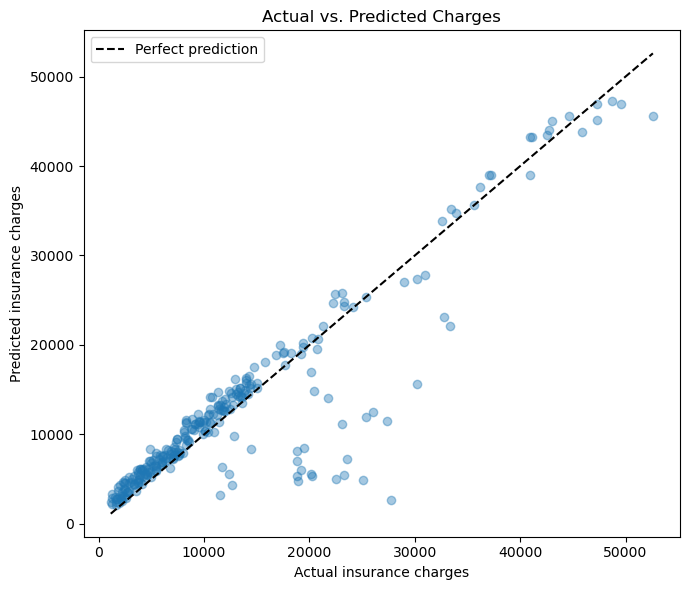

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_test_pred_tuned,
    alpha=0.4
)

minimum = min(y_test.min(), y_test_pred_tuned.min())
maximum = max(y_test.max(), y_test_pred_tuned.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    color="black",
    label="Perfect prediction"
)

plt.xlabel("Actual insurance charges")
plt.ylabel("Predicted insurance charges")
plt.title("Actual vs. Predicted Charges")
plt.legend()
plt.tight_layout()
plt.show()

Many observations lie close to the diagonal especially for lower charges. This indicates that the tuned random forest captures the overall relationship between the predictors and insurance charges. But some predictions around 10000 to 35000 are strongly underpredicted. The same for some actual high charges.

To investigate whether prediction errors vary systematically across the prediction range, we next plot the residuals against the predicted charges. Ideally, the residuals should be distributed randomly around zero without a clear pattern.

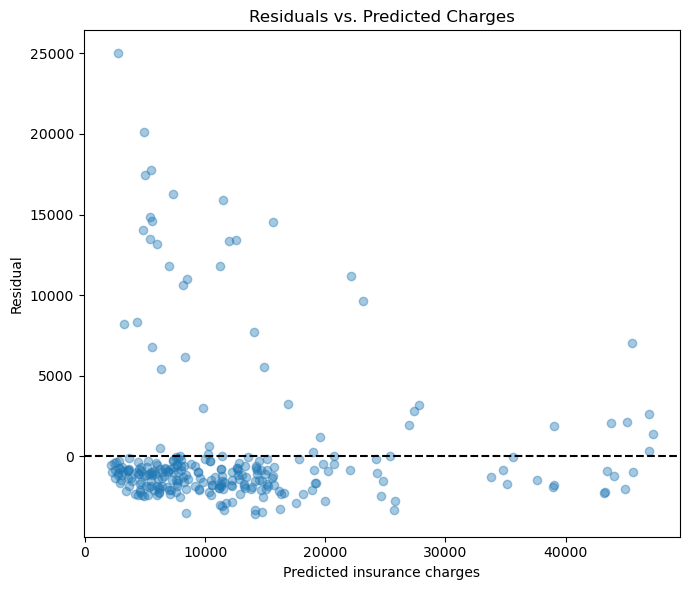

In [18]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_pred_tuned,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--",
    color="black"
)

plt.xlabel("Predicted insurance charges")
plt.ylabel("Residual")
plt.title("Residuals vs. Predicted Charges")
plt.tight_layout()
plt.show()

- most observations have moderate negative residuals, which means that the model ofen overpredicts charges
- a smaller group has verly large positive residuals, which means these cases are clearly underpredicted
- these large underpredictions occur mostly when the predicted charges are below roughly 20000

=> this pattern suggest that the model fails to identify some observations with substantially higher charges and instead assigns them predictions similar to lower cost cases 

Next we visualize the distribution of the residuals

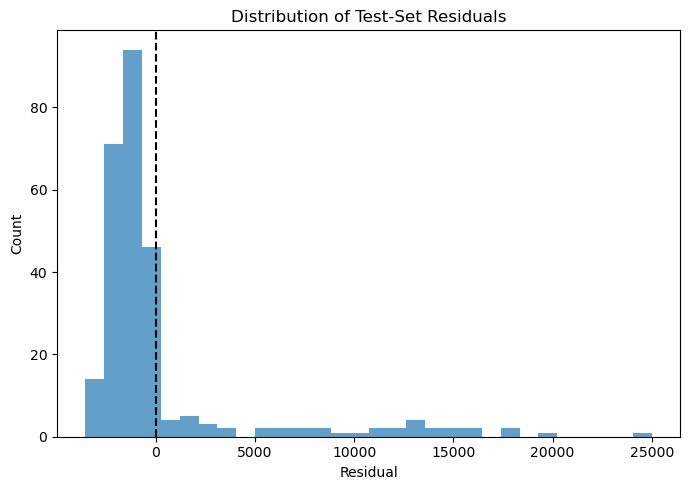

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.hist(
    residuals,
    bins=30,
    density=False,
    alpha=0.7
)

plt.axvline(
    x=0,
    linestyle="--",
    color="black"
)

plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Distribution of Test-Set Residuals")
plt.tight_layout()
plt.show()

The pattern we have already seen is confirmed:

- Most residuals are slightly negative, so the model often overpredicts chargess
- The distribution is strongly right skewed
- A small number of cases have very large positive residuals, which means that the model clearly underpredicts them
- These few large errors explain why the mean residual is positive even though the median residual is negative

Since these two error directions may have different causes, they are examined separately. We first quantify their frequency. We then investigate if people with overpredictions or severe underpredictions have certain characteristic feature profiles?

In [56]:
error_analysis = X_test.copy()

# add the columns which are neccessary to conduct a clear error analysis
error_analysis["actual_charges"] = y_test 
error_analysis["predicted_charges"] = y_test_pred_tuned
error_analysis["residual"] = residuals
error_analysis["absolute_res"] = np.abs(residuals)

Now frequency of overpredictions and underprredictions:

In [58]:
error_analysis["error_direction"] = np.where(error_analysis["residual"] < 0, "Overprediction", "Underprediction")

In [59]:
error_direction_frequency = (error_analysis["error_direction"].value_counts().to_frame(name="count"))

error_direction_frequency["proportion"] = (error_direction_frequency["count"]/ len(error_analysis))

error_direction_frequency

,count,proportion
error_direction,,
Overprediction,219,0.820225
Underprediction,48,0.179775


The model overpredicts insurance charges for 219 of the 267 test observations, corresponding to approximately 82.0% of the test set. In contrast, only 48 observations, or approximately 18.0%, are underpredicted. This confirms that the residual distribution is strongly asymmetric overpredictions are much more frequent than underpredictions.

The next step is to compare the typical and maximum error magnitude in both directions:

In [60]:
error_direction_summary = (
    error_analysis
    .groupby("error_direction")["residual"]
    .agg(
        count="count",
        mean_residual="mean",
        median_residual="median",
        mean_absolute_error=lambda x: x.abs().mean(),
        maximum_absolute_error=lambda x: x.abs().max()
    )
)

error_direction_summary

,count,mean_residual,median_residual,mean_absolute_error,maximum_absolute_error
error_direction,,,,,
Overprediction,219,-1409.503135,-1346.849920,1409.503135,3550.484250
Underprediction,48,7769.513393,6919.390476,7769.513393,24997.064443


Overpredictions are much more frequent, but compared with underpredictions moderate. Their mean absolute error is approximately 1,410, and the largest overprediction is about 3,550. Underpredictions are less frequent, but clearly  higher, with a mean absolute error of approximately 7,770 and a maximum error of almost 25,000. This confirms that the two error directions should be investigated separately.

We will look in the two error directions now, we start by defining the two analysis groups:

In [61]:
overpredicted_cases = error_analysis[error_analysis["residual"] < 0].copy()

underpredicted_cases = error_analysis[error_analysis["residual"] > 0].copy()

### **Analysis of overpredicted cases**

Do overpredicted observations have characteristic feature profiles compared with the overall test set?

In [62]:
numerical_features = ["age", "bmi", "children", "blood_pressure", "annual_income","actual_charges"]

overprediction_numerical_profile = pd.DataFrame({
    "Full test set": error_analysis[numerical_features].median(),
    "Overpredicted cases": overpredicted_cases[numerical_features].median()
})

overprediction_numerical_profile["difference"] = (
    overprediction_numerical_profile["Overpredicted cases"]
    - overprediction_numerical_profile["Full test set"]
)

overprediction_numerical_profile

,Full test set,Overpredicted cases,difference
age,40.00,40.00,0.00
bmi,30.30,30.30,0.00
children,1.00,0.00,-1.00
blood_pressure,124.70,125.00,0.30
annual_income,108077.82,109777.07,1699.25
actual_charges,9625.92,8116.68,-1509.24


In [63]:
categorical_features = ["pre_existing_condition", "sex_male", "smoker_yes", "region_northwest", "region_southeast", "region_southwest",
    "exercise_frequency_never", "exercise_frequency_rarely", "exercise_frequency_weekly", "occupation_risk_low", "occupation_risk_moderate"]

overprediction_categorical_profile = pd.DataFrame({
    "Full test set": error_analysis[categorical_features].mean(),
    "Overpredicted cases": overpredicted_cases[categorical_features].mean()
})

overprediction_categorical_profile["difference"] = (
    overprediction_categorical_profile["Overpredicted cases"]
    - overprediction_categorical_profile["Full test set"]
)

overprediction_categorical_profile

,Full test set,Overpredicted cases,difference
pre_existing_condition,0.505618,0.506849,0.001231
sex_male,0.494382,0.470320,-0.024062
smoker_yes,0.183521,0.146119,-0.037402
region_northwest,0.228464,0.232877,0.004412
region_southeast,0.284644,0.273973,-0.010672
region_southwest,0.239700,0.251142,0.011441
exercise_frequency_never,0.172285,0.182648,0.010364
exercise_frequency_rarely,0.292135,0.315068,0.022934
exercise_frequency_weekly,0.292135,0.264840,-0.027295
occupation_risk_low,0.314607,0.305936,-0.008671


The comparison reveals that overpredicted observations have substantially lower actual insurance charges than the overall test set, with a median difference of approximately 1,509. This suggests that the model’s frequent overpredictions are mainly concentrated among lower-cost observations. In contrast, age, BMI, blood pressure, income, and most categorical characteristics differ only slightly. Therefore, there is no strong evidence that overpredicted cases are defined by a distinct demographic or health-related profile beyond their lower observed charges.

In [64]:
error_analysis["actual_charge_group"] = pd.qcut(
    error_analysis["actual_charges"],
    q=5,
    duplicates="drop"
)

overprediction_by_charge = (
    error_analysis
    .groupby("actual_charge_group", observed=True)
    .agg(
        count=("residual", "count"),
        overprediction_rate=("residual", lambda x: (x < 0).mean()),
        median_residual=("residual", "median")
    )
)

overprediction_by_charge

,count,overprediction_rate,median_residual
actual_charge_group,,,
"(1141.444, 4167.767]",54,1.000000,-1279.272498
"(4167.767, 7571.706]",53,0.981132,-1090.335188
"(7571.706, 11741.119]",53,0.886792,-1493.543023
"(11741.119, 19323.236]",53,0.811321,-1077.928008
"(19323.236, 52590.829]",54,0.425926,1298.126778


The overprediction rate decreases strongly with increasing actual insurance charges. All observations in the lowest charge quintile are overpredicted, whereas only 42.6% of observations in the highest quintile are overpredicted. Furthermore, the median residual is negative in the first four quintiles but becomes positive in the highest quintile. This indicates that the model systematically overpredicts lower-cost cases and tends to underpredict the most expensive cases.

### **Analysis of Severely Underpredicted Cases**

In [65]:
underprediction_numerical_profile = pd.DataFrame({
    "Full test set": error_analysis[numerical_features].median(),
    "Underpredicted cases": underpredicted_cases[numerical_features].median()
})

underprediction_numerical_profile["difference"] = (
    underprediction_numerical_profile["Underpredicted cases"]
    - underprediction_numerical_profile["Full test set"]
)

underprediction_numerical_profile

,Full test set,Underpredicted cases,difference
age,40.00,41.500000,1.500000
bmi,30.30,30.637500,0.337500
children,1.00,2.000000,1.000000
blood_pressure,124.70,124.650000,-0.050000
annual_income,108077.82,99639.330000,-8438.490000
actual_charges,9625.92,21285.314075,11659.394075


In [66]:
underprediction_categorical_profile = pd.DataFrame({
    "Full test set": error_analysis[categorical_features].mean(),
    "Underpredicted cases": underpredicted_cases[categorical_features].mean()
})

underprediction_categorical_profile["difference"] = (
    underprediction_categorical_profile["Underpredicted cases"]
    - underprediction_categorical_profile["Full test set"]
)

underprediction_categorical_profile

,Full test set,Underpredicted cases,difference
pre_existing_condition,0.505618,0.500000,-0.005618
sex_male,0.494382,0.604167,0.109785
smoker_yes,0.183521,0.354167,0.170646
region_northwest,0.228464,0.208333,-0.020131
region_southeast,0.284644,0.333333,0.048689
region_southwest,0.239700,0.187500,-0.052200
exercise_frequency_never,0.172285,0.125000,-0.047285
exercise_frequency_rarely,0.292135,0.187500,-0.104635
exercise_frequency_weekly,0.292135,0.416667,0.124532
occupation_risk_low,0.314607,0.354167,0.039560


Underpredicted observations have substantially higher actual insurance charges than the overall test set, with a median difference of approximately 11,659. They also contain a notably larger proportion of smokers, 35.4% compared with 18.4% in the full test set. Smaller differences are visible for sex, number of children, exercise frequency, and annual income. Overall, the results suggest that underprediction is particularly associated with high-cost cases and may be more common among smokers.

To investigate the largest underpredictions while retaining a sufficiently large group for descriptive comparison, severe underpredictions were defined as observations with positive residuals above the median positive residual. This selects the larger half of all underpredictions.

In [67]:
severe_underprediction_threshold = (
    underpredicted_cases["residual"].median()
)

severely_underpredicted_cases = underpredicted_cases[
    underpredicted_cases["residual"] >= severe_underprediction_threshold
].copy()

print("Threshold:", severe_underprediction_threshold)
print("Number of severe underpredictions:", len(severely_underpredicted_cases))

Threshold: 6919.390476120194
Number of severe underpredictions: 24


In [68]:
severe_underprediction_numerical_profile = pd.DataFrame({
    "Full test set": error_analysis[numerical_features].median(),
    "All underpredicted cases":
        underpredicted_cases[numerical_features].median(),
    "Severely underpredicted cases":
        severely_underpredicted_cases[numerical_features].median()
})

severe_underprediction_numerical_profile

,Full test set,All underpredicted cases,Severely underpredicted cases
age,40.00,41.500000,32.0000
bmi,30.30,30.637500,30.6375
children,1.00,2.000000,1.0000
blood_pressure,124.70,124.650000,123.9500
annual_income,108077.82,99639.330000,117652.8750
actual_charges,9625.92,21285.314075,22769.6129


In [69]:
severe_underprediction_categorical_profile = pd.DataFrame({
    "Full test set": error_analysis[categorical_features].mean(),
    "All underpredicted cases":
        underpredicted_cases[categorical_features].mean(),
    "Severely underpredicted cases":
        severely_underpredicted_cases[categorical_features].mean()
})

severe_underprediction_categorical_profile

,Full test set,All underpredicted cases,Severely underpredicted cases
pre_existing_condition,0.505618,0.500000,0.458333
sex_male,0.494382,0.604167,0.666667
smoker_yes,0.183521,0.354167,0.125000
region_northwest,0.228464,0.208333,0.291667
region_southeast,0.284644,0.333333,0.333333
region_southwest,0.239700,0.187500,0.125000
exercise_frequency_never,0.172285,0.125000,0.041667
exercise_frequency_rarely,0.292135,0.187500,0.250000
exercise_frequency_weekly,0.292135,0.416667,0.333333
occupation_risk_low,0.314607,0.354167,0.291667


The severely underpredicted observations have slightly higher actual charges than the full underprediction group, but their feature profile differs considerably. They are younger, more often male, and have higher median income. Surprisingly, smokers are less common among the severely underpredicted cases than among all underpredicted cases. Therefore, the largest underpredictions do not appear to be explained by smoking status alone and may represent a distinct subgroup of high-cost observations.